## Regression Diagnostics

In [5]:
import statsmodels.api as sm
from statsmodels.compat import lzip
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [3]:
df = sm.datasets.get_rdataset('Guerry', 'HistData').data

In [6]:
df

,dept,Region,Department,Crime_pers,Crime_prop,Literacy,Donations,Infants,Suicides,MainCity,Wealth,Commerce,Clergy,Crime_parents,Infanticide,Donation_clergy,Lottery,Desertion,Instruction,Prostitutes,Distance,Area,Pop1831
0,1,E,Ain,28870,15890,37,5098,33120,35039,2:Med,73,58,11,71,60,69,41,55,46,13,218.372,5762,346.03
1,2,N,Aisne,26226,5521,51,8901,14572,12831,2:Med,22,10,82,4,82,36,38,82,24,327,65.945,7369,513.00
2,3,C,Allier,26747,7925,13,10973,17044,114121,2:Med,61,66,68,46,42,76,66,16,85,34,161.927,7340,298.26
3,4,E,Basses-Alpes,12935,7289,46,2733,23018,14238,1:Sm,76,49,5,70,12,37,80,32,29,2,351.399,6925,155.90
4,5,E,Hautes-Alpes,17488,8174,69,6962,23076,16171,1:Sm,83,65,10,22,23,64,79,35,7,1,320.280,5549,129.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,86,W,Vienne,15010,4710,25,8922,35224,21851,2:Med,68,43,71,20,1,44,40,38,65,18,170.523,6990,282.73
82,87,C,Haute-Vienne,16256,6402,13,13817,19940,33497,2:Med,67,63,76,68,6,78,55,11,84,7,198.874,5520,285.13
83,88,E,Vosges,18835,9044,62,4040,14978,33029,2:Med,82,42,51,58,34,5,14,85,11,43,174.477,5874,397.99
84,89,C,Yonne,18006,6516,47,4276,16616,12789,2:Med,30,15,55,32,22,35,51,66,27,272,81.797,7427,352.49


In [7]:
res = smf.ols("Lottery~Literacy + np.log(Pop1831)", data=df).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Lottery   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     22.20
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.90e-08
Time:                        06:14:18   Log-Likelihood:                -379.82
No. Observations:                  86   AIC:                             765.6
Df Residuals:                      83   BIC:                             773.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         246.4341     35.233      6.995      0.000     176.358     316.510
Literacy           -0.4889      0.128     -3.832      0.000      -0.743      -0.235
np.log(Pop1831)   -31.3114      5.977     -5.239      0.000     -43.199     -19.424
==============================================================================
Omnibus:                        3.713   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.156   Jarque-Bera (JB):                3.394
Skew:                          -0.487   Prob(JB):                        0.183
Kurtosis:                       3.003   Cond. No.                         702.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Normality of residuals
#### Jarque-Bera Test:

In [8]:
name = ["Jarque-Bera", "Chi^2 two-tail prob.", "Skew", "Kurtosis"]

In [9]:
test = sms.jarque_bera(res.resid)
lzip(name, test)

[('Jarque-Bera', np.float64(3.39360802484318)),
 ('Chi^2 two-tail prob.', np.float64(0.18326831231663254)),
 ('Skew', np.float64(-0.4865803431122347)),
 ('Kurtosis', np.float64(3.003417757881634))]

#### Influence Tests

In [10]:
from statsmodels.stats.outliers_influence import OLSInfluence

In [11]:
test_class = OLSInfluence(res)

In [12]:
test_class.dfbeta[5:, :]

array([[ 8.26794653e-01, -9.37228508e-03, -3.91782694e-02],
       [-4.60565242e-01, -6.00836231e-03,  1.07905336e-01],
       [ 2.20296666e+00, -8.83371102e-03, -2.94410442e-01],
       [-3.09677967e+00, -1.44344868e-02,  5.88879087e-01],
       [-6.94207982e-01,  8.22842167e-04,  1.03706847e-01],
       [ 4.10842584e-01, -1.11761663e-02,  7.29888204e-02],
       [-1.89562753e-01,  2.08460190e-03, -6.30431760e-02],
       [ 2.38248735e+00, -6.58585145e-03, -3.89952698e-01],
       [ 4.44134010e+00, -7.37883826e-03, -6.57505666e-01],
       [ 3.65734696e-02, -2.06183483e-03,  3.90285143e-02],
       [ 1.48071908e-01,  4.65456319e-05, -2.83829919e-02],
       [-4.66538011e+00,  2.34268272e-02,  5.91701800e-01],
       [ 2.88977165e+00, -2.35317798e-02, -2.90569539e-01],
       [-6.22764720e-02,  1.28974407e-03,  5.15640285e-03],
       [-8.19834682e+00, -3.43559449e-02,  1.69772160e+00],
       [ 4.31761529e+00, -1.53701973e-02, -5.82861140e-01],
       [-4.22405692e+00, -2.94719098e-02

In [13]:
from statsmodels.graphics.regressionplots import plot_leverage_resid2

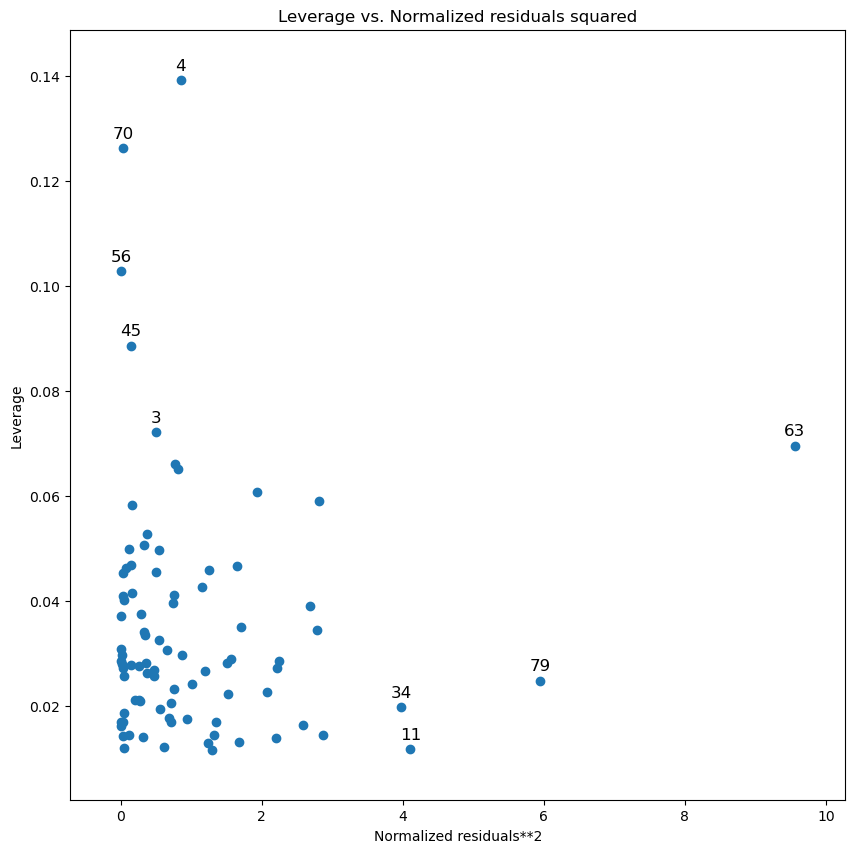

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))
fit = plot_leverage_resid2(res, ax=ax)

#### Multicollinearity

In [15]:
np.linalg.cond(res.model.exog)

np.float64(702.1792145490066)

#### Heteroskedasticity

In [17]:
name = ["Lagrange multiplier stat", "p-value", "f-value", "f p-value"]
test = sms.het_breuschpagan(res.resid, res.model.exog)
lzip(name, test)

[('Lagrange multiplier stat', np.float64(4.893213374094005)),
 ('p-value', np.float64(0.08658690502352002)),
 ('f-value', np.float64(2.5037159462564618)),
 ('f p-value', np.float64(0.08794028782672814))]

In [19]:
name = ['F stat', 'p-value']
test = sms.het_goldfeldquandt(res.resid, res.model.exog)
lzip(name, test)

[('F stat', np.float64(1.1002422436378143)),
 ('p-value', np.float64(0.38202950686925324))]

#### Linearity

In [20]:
name = ['t value', 'p value']
test = sms.linear_harvey_collier(res)
lzip(name, test)

[('t value', np.float64(-1.0796490077759802)),
 ('p value', np.float64(0.2834639247569222))]